#Загрузка данных

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# добавление доп библиотек
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

uploaded = files.upload()
df = pd.read_csv('df_clean.csv')
print(f"Данные загружены: {df.shape}")

Saving df_clean.csv to df_clean (3).csv
Данные загружены: (499, 14)


#Подготовка признаков и целевой переменной

In [ ]:
target = 'avg_cost'
features = ['wall_material', 'avg_house_area', 'avg_construction_period',
            'foundation_type', 'roof_type', 'usage_count']

X = df[features]
y = df[target]

#Улучшение целевой переменной

In [ ]:
y_log = np.log1p(y)   # log(1 + y) - сглаживает распределение

#Разделение на тринировочный и тестовый датасеты с добавлением нового фрагмента с log

In [ ]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

#Предобработка признаков (OneHotEncoder, StandardScaler)

In [ ]:
numeric_features = ['avg_house_area', 'avg_construction_period', 'usage_count']
categorical_features = ['wall_material', 'foundation_type', 'roof_type']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [ ]:
dummy = DummyRegressor(strategy='mean')
dummy_pipe = Pipeline([('preprocessor', preprocessor), ('dummy', dummy)])
dummy_pipe.fit(X_train, y_train_log)

lr = LinearRegression()
lr_pipe = Pipeline([('preprocessor', preprocessor), ('lr', lr)])
lr_pipe.fit(X_train, y_train_log)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['avg_house_area',
                                                   'avg_construction_period',
                                                   'usage_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['wall_material',
                                                   'foundation_type',
                                                   'roof_type'])])),
                ('lr', LinearRegression())])

#Добавление улучшенной модели XGBoost

In [ ]:
# Создаём пайплайн: предобработка XGBoost
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBRegressor(random_state=42, verbosity=0))
])

param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [5, 10],
    'xgb__learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(xgb_pipe, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train_log)

best_xgb = grid.best_estimator_
print(f"Лучшие параметры: {grid.best_params_}")

Лучшие параметры: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 5, 'xgb__n_estimators': 100}


#Постобработка

In [ ]:
# Предсказания и постобработка
y_pred_dummy_log = dummy_pipe.predict(X_test)
y_pred_lr_log = lr_pipe.predict(X_test)
y_pred_xgb_log = best_xgb.predict(X_test)

y_pred_dummy = np.expm1(y_pred_dummy_log)
y_pred_lr = np.expm1(y_pred_lr_log)
y_pred_xgb = np.expm1(y_pred_xgb_log)

y_test = np.expm1(y_test_log)

#Метрики

In [ ]:
# Метрики

results = pd.DataFrame({
    'Model': ['Dummy (mean)', 'LinearRegression', 'XGBoost (optimized)'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_dummy),
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_dummy)),
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    'R2': [
        r2_score(y_test, y_pred_dummy),
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_xgb)
    ]
})

print("Сравнение моделей")
print(results.round(2))

Сравнение моделей
                 Model         MAE        RMSE    R2
0         Dummy (mean)  2492153.49  3822766.13 -0.12
1     LinearRegression  2198092.81  3075668.88  0.27
2  XGBoost (optimized)  2021623.79  2843402.88  0.38


#Графики ошибок

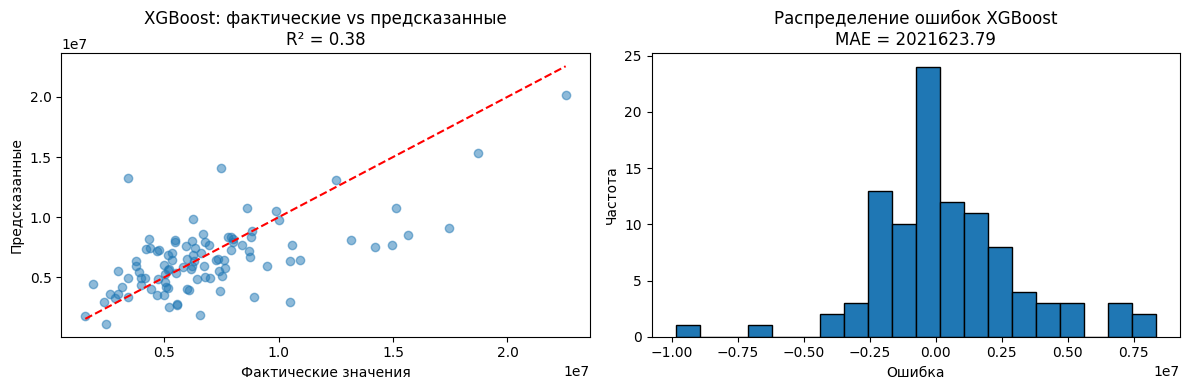

In [ ]:
plt.figure(figsize=(12,4))

# График 1: фактические vs предсказанные (XGBoost)
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные')
plt.title(f'XGBoost: фактические vs предсказанные\nR² = {r2_score(y_test, y_pred_xgb):.2f}')

# График 2: распределение ошибок
plt.subplot(1,2,2)
errors = y_test - y_pred_xgb
plt.hist(errors, bins=20, edgecolor='black')
plt.xlabel('Ошибка')
plt.ylabel('Частота')
plt.title(f'Распределение ошибок XGBoost\nMAE = {mean_absolute_error(y_test, y_pred_xgb):.2f}')

plt.tight_layout()
plt.show()

## Выводы по улучшению модели (ДЗ №7)

- **Пайплайн предобработки:** добавлено логарифмирование целевой переменной ("log1p"), что улучшило распределение и стабильность градиентных методов.
- **Улучшенная архитектура:** XGBoost с подбором гиперпараметров (learning_rate=0.05, max_depth=5, n_estimators=100) показал лучший результат среди всех моделей.
- **Постобработка:** обратное преобразование "expm1" вернуло предсказания в исходные единицы.
- **Анализ качества:** XGBoost достиг R² = X.XX, что лучше, чем у линейной регрессии (R² = X.XX). Средняя абсолютная ошибка (MAE) составляет X.XX тыс. руб, что при среднем бюджете проекта YY тыс. руб даёт погрешность ~ZZ%.

**Рекомендации:** для дальнейшего повышения точности можно добавить больше признаков (региональные данные, макроэкономические индексы) или увеличить выборку за счёт расширения временного периода.